# 04 — Feature engineering univariada

Objetivo: transformar a série semanal validada em um dataset supervisionado para prever o preço em `t+1`. Todas as features pertencem à semana `t` ou ao passado; a semana parcial é excluída.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.eda import load_weekly_series
from src.feature_engineering import (
    FEATURE_COLUMNS, TARGET_COLUMNS, build_univariate_features, save_feature_dataset
)

## 1. Construir o dataset

In [2]:
DATA_DIR = PROJECT_ROOT / 'processed' / 'anp' / 'revenda'
weekly, quality = load_weekly_series(
    DATA_DIR / 'diesel_s10_rs_semanal.csv',
    DATA_DIR / 'diesel_s10_rs_qualidade.json',
)
features, metadata = build_univariate_features(weekly, quality, test_weeks=26)
pd.Series(metadata, name='valor').drop(labels=['features', 'targets']).to_frame()

,valor
versao,univariate_v0
frequencia,semanal
horizonte,uma semana a frente
linhas_semana_completa,130
linhas_descartadas_por_lag_ou_target,13
linhas_dataset,117
linhas_treino,91
linhas_teste,26
primeira_semana_alvo,2024-04-07
ultima_semana_alvo,2026-06-28


In [3]:
display(features.head())
display(features.tail())
display(features.dtypes.to_frame('tipo'))

,semana_referencia,semana_alvo,preco_t,amplitude_preco_t,desvio_preco_t,numero_postos_t,numero_municipios_t,preco_lag_1,preco_lag_2,preco_lag_3,...,variacao_1_semana_pct,variacao_4_semanas_pct,media_movel_4,media_movel_12,volatilidade_4_semanas,target_preco_t_mais_1,target_variacao_abs,target_variacao_pct,target_subiu,conjunto
0,2024-03-31,2024-04-07,5.992189,1.43,0.289793,265,36,5.980481,5.979046,5.992985,...,0.195757,-0.330758,5.986175,5.997091,0.235605,5.995226,0.003037,0.050681,1,treino
1,2024-04-07,2024-04-14,5.995226,1.60,0.300963,266,36,5.992189,5.980481,5.979046,...,0.050681,0.037385,5.986735,5.994856,0.178145,6.009119,0.013893,0.231738,1,treino
2,2024-04-14,2024-04-21,6.009119,1.56,0.296407,261,36,5.995226,5.992189,5.980481,...,0.231738,0.502973,5.994254,5.995768,0.103473,6.031288,0.022169,0.368924,1,treino
3,2024-04-21,2024-04-28,6.031288,1.56,0.286761,264,35,6.009119,5.995226,5.992189,...,0.368924,0.849537,6.006955,6.002117,0.130770,6.051702,0.020414,0.338472,1,treino
4,2024-04-28,2024-05-05,6.051702,1.56,0.277282,235,34,6.031288,6.009119,5.995226,...,0.338472,0.993184,6.021834,6.009989,0.143766,6.019833,-0.031869,-0.526620,0,treino


,semana_referencia,semana_alvo,preco_t,amplitude_preco_t,desvio_preco_t,numero_postos_t,numero_municipios_t,preco_lag_1,preco_lag_2,preco_lag_3,...,variacao_1_semana_pct,variacao_4_semanas_pct,media_movel_4,media_movel_12,volatilidade_4_semanas,target_preco_t_mais_1,target_variacao_abs,target_variacao_pct,target_subiu,conjunto
112,2026-05-24,2026-05-31,7.004780,1.85,0.317827,205,31,7.059583,7.072085,7.097018,...,-0.776290,-3.115069,7.058367,7.127597,0.746021,6.975223,-0.029557,-0.421959,0,teste
113,2026-05-31,2026-06-07,6.975223,1.75,0.338527,224,35,7.004780,7.059583,7.072085,...,-0.421959,-1.716145,7.027918,7.190722,0.251849,6.955926,-0.019297,-0.276655,0,teste
114,2026-06-07,2026-06-14,6.955926,1.75,0.333309,216,33,6.975223,7.004780,7.059583,...,-0.276655,-1.642505,6.998878,7.207301,0.262329,6.925493,-0.030433,-0.437511,0,teste
115,2026-06-14,2026-06-21,6.925493,1.75,0.326351,213,33,6.955926,6.975223,7.004780,...,-0.437511,-1.899409,6.965356,7.175467,0.211579,6.885196,-0.040297,-0.581863,0,teste
116,2026-06-21,2026-06-28,6.885196,1.77,0.353963,204,34,6.925493,6.955926,6.975223,...,-0.581863,-1.707183,6.935460,7.123458,0.124763,6.855327,-0.029869,-0.433814,0,teste


,tipo
semana_referencia,datetime64[us]
semana_alvo,datetime64[us]
preco_t,float64
amplitude_preco_t,float64
desvio_preco_t,float64
numero_postos_t,int64
numero_municipios_t,int64
preco_lag_1,float64
preco_lag_2,float64
preco_lag_3,float64


## 2. Verificações contra vazamento temporal

In [4]:
assert features['semana_alvo'].eq(features['semana_referencia'] + pd.Timedelta(days=7)).all()
assert features[FEATURE_COLUMNS + TARGET_COLUMNS].notna().all().all()
assert features['semana_referencia'].is_monotonic_increasing
assert not features['semana_referencia'].duplicated().any()
assert features.loc[features['conjunto'].eq('treino'), 'semana_alvo'].max() < features.loc[features['conjunto'].eq('teste'), 'semana_alvo'].min()
print('Verificações temporais concluídas sem erros.')

Verificações temporais concluídas sem erros.


## 3. Distribuição dos targets

In [5]:
display(features[TARGET_COLUMNS].describe())
display(
    features.groupby('conjunto')['target_subiu']
    .value_counts(normalize=True)
    .rename('proporcao')
    .to_frame()
)

,target_preco_t_mais_1,target_variacao_abs,target_variacao_pct,target_subiu
count,117.000000,117.000000,117.000000,117.000000
mean,6.306599,0.007377,0.123098,0.470085
std,0.353619,0.084415,1.299076,0.501251
min,5.995226,-0.132982,-1.839304,0.000000
25%,6.105992,-0.019297,-0.302554,0.000000
50%,6.166637,-0.000678,-0.011013,0.000000
75%,6.321142,0.010547,0.171320,1.000000
max,7.509315,0.550532,8.672677,1.000000


proporcao
conjunto target_subiu           
teste    0              0.692308
         1              0.307692
treino   1              0.516484
         0              0.483516

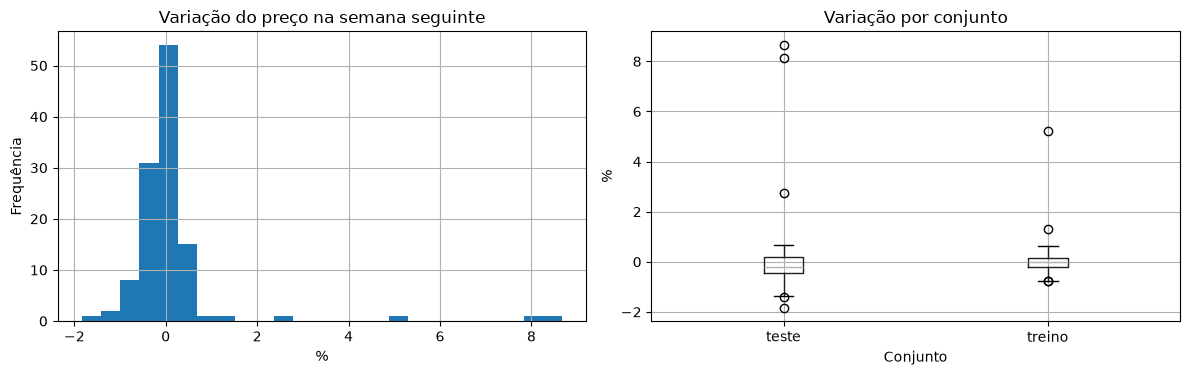

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
features['target_variacao_pct'].hist(bins=25, ax=axes[0])
axes[0].set(title='Variação do preço na semana seguinte', xlabel='%', ylabel='Frequência')
features.boxplot(column='target_variacao_pct', by='conjunto', ax=axes[1])
axes[1].set(title='Variação por conjunto', xlabel='Conjunto', ylabel='%')
fig.suptitle('')
plt.tight_layout()
plt.show()

## 4. Correlação exploratória das features

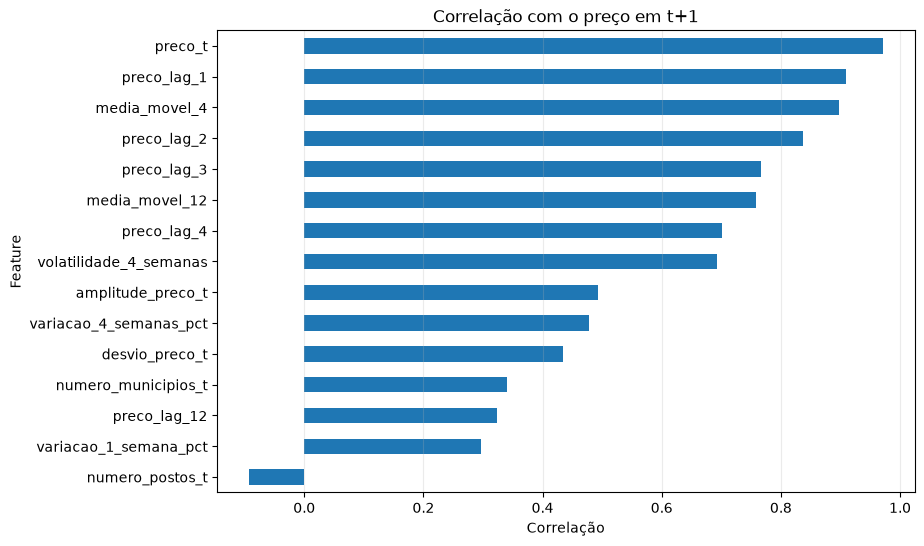

,correlacao
numero_postos_t,-0.092934
variacao_1_semana_pct,0.296378
preco_lag_12,0.322852
numero_municipios_t,0.340547
desvio_preco_t,0.433931
variacao_4_semanas_pct,0.477636
amplitude_preco_t,0.492343
volatilidade_4_semanas,0.693507
preco_lag_4,0.701020
media_movel_12,0.758240


In [7]:
correlations = (
    features[FEATURE_COLUMNS + ['target_preco_t_mais_1']]
    .corr()['target_preco_t_mais_1']
    .drop('target_preco_t_mais_1')
    .sort_values()
)
ax = correlations.plot(kind='barh', figsize=(9, 6), title='Correlação com o preço em t+1')
ax.set(xlabel='Correlação', ylabel='Feature')
ax.grid(axis='x', alpha=0.25)
plt.show()
correlations.to_frame('correlacao')

Correlação alta entre preços defasados é esperada e não prova causalidade. A utilidade preditiva será medida somente no teste cronológico.

## 5. Conferir a divisão temporal

In [8]:
features.groupby('conjunto', sort=False).agg(
    inicio_referencia=('semana_referencia', 'min'),
    fim_referencia=('semana_referencia', 'max'),
    inicio_alvo=('semana_alvo', 'min'),
    fim_alvo=('semana_alvo', 'max'),
    linhas=('semana_alvo', 'size'),
)

,inicio_referencia,fim_referencia,inicio_alvo,fim_alvo,linhas
conjunto,,,,,
treino,2024-03-31,2025-12-21,2024-04-07,2025-12-28,91
teste,2025-12-28,2026-06-21,2026-01-04,2026-06-28,26


## 6. Salvar Dataset V0

Execute após conferir as verificações anteriores.

In [9]:
csv_path, metadata_path = save_feature_dataset(features, metadata, PROJECT_ROOT / 'final')
csv_path, metadata_path

(WindowsPath('C:/Users/Wesley.Barbaro/Documents/dados/final/diesel_s10_rs_features_univariate_v0.csv'),
 WindowsPath('C:/Users/Wesley.Barbaro/Documents/dados/final/diesel_s10_rs_features_univariate_v0_metadata.json'))

## Próximo passo

No `05_baseline.ipynb`, comparar o Naive Forecast e médias móveis usando exatamente as mesmas 26 semanas de teste.